In [74]:
"""
🧠 ПРОСТИЙ ПЕРЦЕПТРОН З НУЛЯ
Автор: Igorich
Мета: Навчити перцептрон розпізнавати, чи лежить точка (x, y)
      вище або нижче діагоналі y = x.
Мова: Python 3
Бібліотеки: numpy, matplotlib

🧩 Що буде зроблено:
1. Згенеруємо дані (точки)
2. Реалізуємо перцептрон з нуля
3. Навчимо його класифікувати
4. Візуалізуємо результат
"""

# --- імпорт бібліотек ---
import numpy as np # для роботи з масивами та матрицями однакових типів даних
import matplotlib.pyplot as plt # для візуалізації даних та результатів
import random # для генерації випадкових чисел

# --- підготовка даних ---
def generate_data(n=1000):
    X = np.random.uniform(-1, 1, (n, 2)) # генеруємо n точок з координатами від -1 до 1
    y = np.array([1 if x[1] > x[0] else 0 for x in X]) # мітки: 1, якщо y > x, інакше 0
    return X, y

class Perceptron:
    def __init__(self, input_size, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = np.zeros(input_size + 1) # +1 для біаса (зміщення)

    def activation(self,  x):
        return  np.where(x >= 0, 1, -1) # порігова функція активації

    def predict(self, x):
        x_with_bias = np.insert(x, 0, 1) # додаємо біас
        z = np.dot(self.weights, x_with_bias)
        return self.activation(z)

    def fit(self, X, y):
        # навчання перцептрона
        for epoch in range(self.epochs):
            total_errors = 0
            for xi, target in zip(X, y):
                xi_with_bias = np.insert(xi, 0, 1)
                output = self.activation(np.dot(self.weights, xi_with_bias))
                update = self.lr * (target - output)
                self.weights += update * xi_with_bias
                total_errors += int(update != 0.0)

            # Лог навчання
            # print(f"Епоха {epoch+1}/{self.epochs} — помилок: {total_errors}")

            # Якщо вже без помилок — можна завершити
            if total_errors == 0:
                print("✅ Навчання завершено достроково.")
                break

    def score(self, X, y):
        # оцінка точності
        correct = 0
        for xi, target in zip(X, y):
            if self.predict(xi) == target:
                correct += 1
        return correct / len(y)

def plot_decision_boundary(model, X, y):
    """Малюємо межу рішень перцептрона"""
    plt.figure(figsize=(8, 8))

    # дані
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='green', label='y > x')
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='y <= x')

    # межа рішень y = x
    plt.plot([-1, 1], [-1, 1], "--", color='black', label="y = x (межа рішень)")

    # межа рішень перцептрона
    w = model.weights
    x_points = np.linspace(-1, 1, 100)
    y_points = -(w[1] * x_points + w[0]) / w[2]
    plt.plot(x_points, y_points, color='blue', label='Межа рішень перцептрона')

    plt.title("Навчений Перцептрон")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

In [75]:
"""1. Генеруємо навчальні дані"""
X_train, y_train = generate_data(n=800)
X_test, y_test = generate_data(n=200)

In [82]:
"""2. Створюємо та навчаємо перцептрон"""
perceptron = Perceptron(input_size=2, learning_rate=0.05, epochs=2000)
perceptron.fit(X_train, y_train)

In [83]:
"""3. Оцінюємо модель"""
accuracy = perceptron.score(X_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 45.00%


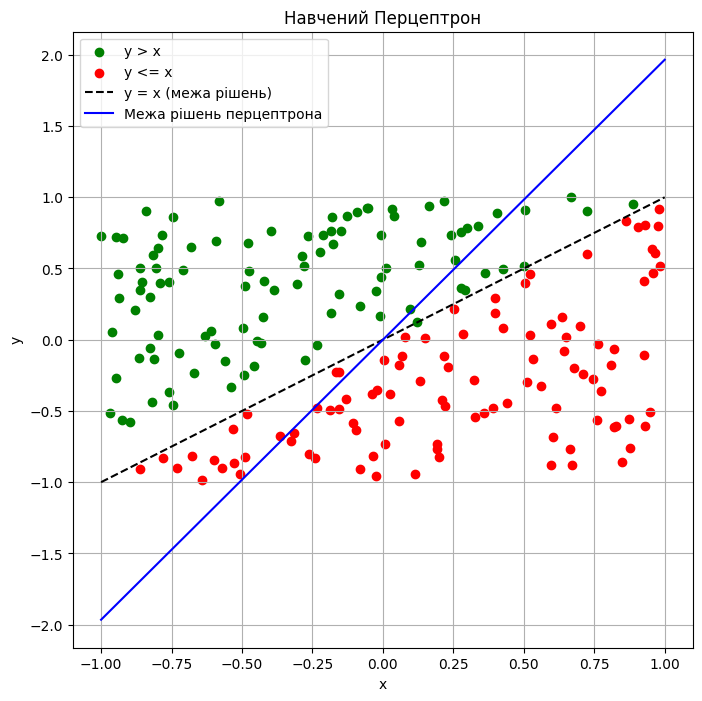

In [84]:
"""4. Візуалізуємо результати"""
plot_decision_boundary(perceptron, X_test, y_test)